Dataset:
    x  y
1  3  2
2  3  5
3  5  3
4  6  4
5  6  7 

Euclidean Distance Matrix:
           1         2         3         4         5
1  0.000000  3.000000  2.236068  3.605551  5.830952
2  3.000000  0.000000  2.828427  3.162278  3.605551
3  2.236068  2.828427  0.000000  1.414214  4.123106
4  3.605551  3.162278  1.414214  0.000000  3.000000
5  5.830952  3.605551  4.123106  3.000000  0.000000 

Linkage Matrix (Stepwise merges):
 [[2.         3.         1.41421356 2.        ]
 [0.         5.         2.23606798 3.        ]
 [1.         6.         2.82842712 4.        ]
 [4.         7.         3.         5.        ]] 



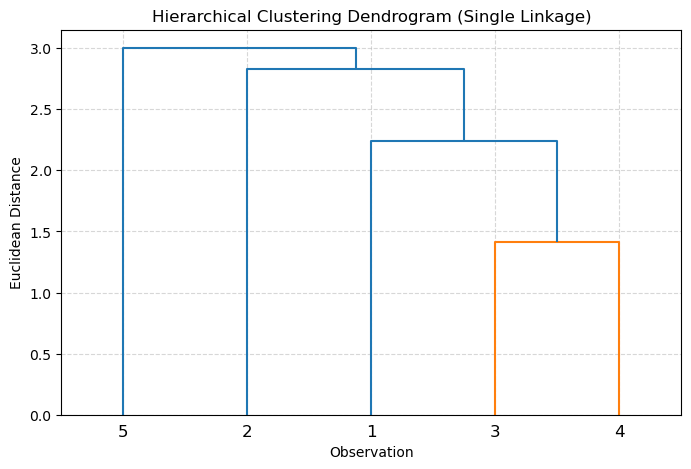


Interpretation of the Linkage Steps:
-----------------------------------
Each row of the linkage matrix shows which clusters merged and at what distance.

Example (from Z):
[2, 3, 1.414, 2] means:
- Cluster 2 and 3 merged first (distance = 1.41)
- This new cluster now contains 2 points

The dendrogram confirms that points 3 and 4 are closest,
then other points merge step-by-step exactly as the algorithm would by hand.



In [1]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# -----------------------------------------
# STEP 1: Create the dataset
# -----------------------------------------
data = pd.DataFrame({
    'x': [3, 3, 5, 6, 6],
    'y': [2, 5, 3, 4, 7]
}, index=['1', '2', '3', '4', '5'])

print("Dataset:\n", data, "\n")

# -----------------------------------------
# STEP 2: Compute the pairwise distance matrix manually
# -----------------------------------------
dist_matrix = squareform(pdist(data, metric='euclidean'))
dist_df = pd.DataFrame(dist_matrix, index=data.index, columns=data.index)
print("Euclidean Distance Matrix:\n", dist_df, "\n")

# -----------------------------------------
# STEP 3: Hierarchical clustering using SciPy (single linkage)
# -----------------------------------------
Z = linkage(data, method='single', metric='euclidean')
print("Linkage Matrix (Stepwise merges):\n", Z, "\n")

# Z columns:
# [idx1, idx2, distance, cluster_size]

# -----------------------------------------
# STEP 4: Plot dendrogram
# -----------------------------------------
plt.figure(figsize=(8, 5))
dendrogram(Z, labels=data.index.tolist(), distance_sort='ascending')
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
plt.xlabel("Observation")
plt.ylabel("Euclidean Distance")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# -----------------------------------------
# STEP 5: Explanation for classroom
# -----------------------------------------
print("""
Interpretation of the Linkage Steps:
-----------------------------------
Each row of the linkage matrix shows which clusters merged and at what distance.

Example (from Z):
[2, 3, 1.414, 2] means:
- Cluster 2 and 3 merged first (distance = 1.41)
- This new cluster now contains 2 points

The dendrogram confirms that points 3 and 4 are closest,
then other points merge step-by-step exactly as the algorithm would by hand.
""")
